In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Dense, Flatten

In [2]:
train_df=pd.read_csv('fashion-mnist_train.csv')
test_df=pd.read_csv('fashion-mnist_test.csv')

In [3]:
print(train_df.head())
print(train_df.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
1       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2       0  ...       0.0       0.0       0.0      30.0      43.0       0.0   
3       0  ...       3.0       0.0       0.0       0.0       0.0       1.0   
4       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel781  pixel782  pixel783  pixel784  
0       0.0       0.0       0.

In [6]:
x_train=train_df.iloc[:,1:].values
y_train=train_df.iloc[:,0].values

x_test=test_df.iloc[:,1:].values
y_test=test_df.iloc[:,0].values

In [7]:
x_train=x_train/255.0
x_test=x_test/255.0

In [8]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [10]:
class_names=[
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [11]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(62,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │       335,358 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,308 (1.28 MB)

 Trainable params: 336,308 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(x_train,y_train,epochs=50,batch_size=1200,validation_split=0.2)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.8588 - loss: 0.4168 - val_accuracy: 0.8333 - val_loss: nan
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 362ms/step - accuracy: 0.8516 - loss: 0.4300 - val_accuracy: 0.7910 - val_loss: nan
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.8482 - loss: 0.4225 - val_accuracy: 0.8228 - val_loss: nan
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.8608 - loss: 0.3936 - val_accuracy: 0.8280 - val_loss: nan
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.8535 - loss: 0.4045 - val_accuracy: 0.8439 - val_loss: nan
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 0.8529 - loss: 0.4021 - val_accuracy: 0.8466 - val_loss: nan
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 0.8694 - loss: 0.3774 - val_accuracy: 0.8307 - val_loss: nan
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 0.8774 - loss: 0.3720 - val_accuracy: 0.8360 - val_loss: nan
Epoch 9/50
2/2 ━

In [20]:
loss,accuracy=model.evaluate(x_test,y_test)
print("Test accuracy: ",accuracy)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8388 - loss: nan   
Test accuracy:  0.8388122916221619


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


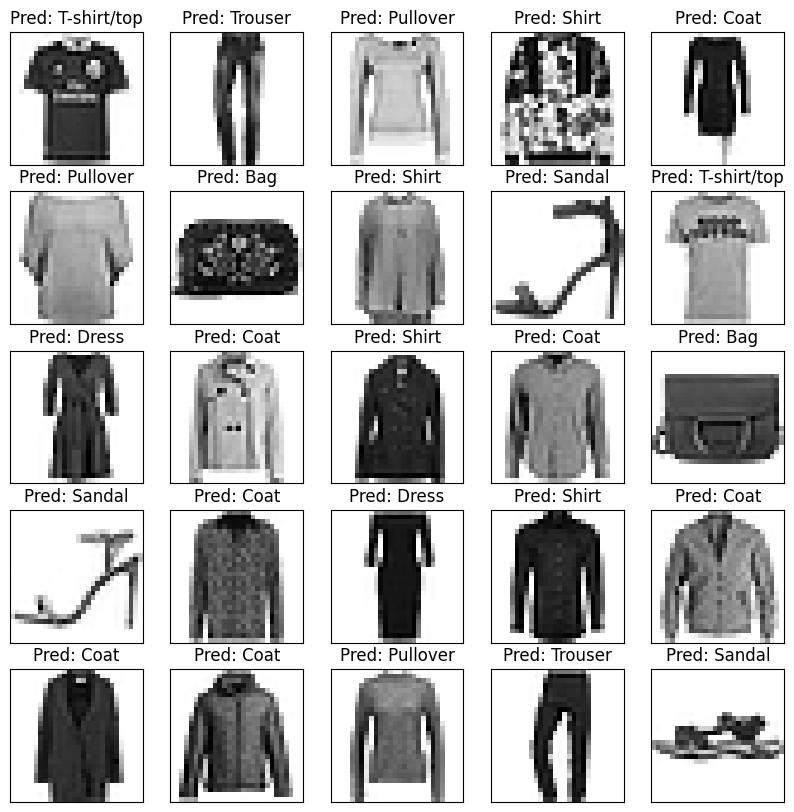

In [25]:
predictions = model.predict(x_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])

    plt.grid(False)

    plt.imshow(
        x_test[i].reshape(28,28),
        cmap=plt.cm.binary
    )

    plt.title(f"Pred: {class_names[predicted_labels[i]]}")

plt.show()